In [7]:
# Convolutional Neural Network (CNN) using Fashion MNIST Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [8]:
# Load CSV Files
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [9]:
# Display First 5 Rows

print(train_df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [10]:
# Split Features and Labels

X_train = train_df.iloc[:, 1:].values

y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values

In [11]:
# Normalize Pixel Values

X_train = X_train / 255.0

X_test = X_test / 255.0

In [12]:
# Reshape for CNN

X_train = X_train.reshape(-1, 28, 28, 1)

X_test = X_test.reshape(-1, 28, 28, 1)

In [13]:
# One Hot Encoding

y_train_cat = to_categorical(y_train, 10)

y_test_cat = to_categorical(y_test, 10)

In [14]:
# Class Labels

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [15]:
# Build CNN Model

model = Sequential()

In [16]:
# First Convolution Layer

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# First Pooling Layer

model.add(MaxPooling2D((2,2)))

In [18]:
# Second Convolution Layer

model.add(Conv2D(64, (3,3), activation='relu'))

In [19]:
# Second Pooling Layer

model.add(MaxPooling2D((2,2)))

In [20]:
# Flatten Layer

model.add(Flatten())

In [21]:
# Fully Connected Layer

model.add(Dense(128, activation='relu'))

In [22]:
# Dropout Layer

model.add(Dropout(0.5))

In [23]:
# Output Layer

model.add(Dense(10, activation='softmax'))

In [24]:
# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
# Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train Model
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7743 - loss: 0.6190 - val_accuracy: 0.8613 - val_loss: 0.3974
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8535 - loss: 0.4077 - val_accuracy: 0.8787 - val_loss: 0.3322
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8727 - loss: 0.3507 - val_accuracy: 0.8846 - val_loss: 0.3146
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8839 - loss: 0.3213 - val_accuracy: 0.8989 - val_loss: 0.2834
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8936 - loss: 0.2937 - val_accuracy: 0.8960 - val_loss: 0.2861
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8997 - loss: 0.2748 - val_accuracy: 0.9098 - val_loss: 0.2548
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9053 - loss: 0.2531 - val_accuracy: 0.9094 - val_loss: 0.2540
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9115 - loss: 0.2437 - val_accuracy: 0.

In [27]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("\nTest Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9119 - loss: 0.2417

Test Accuracy : 0.911899983882904


In [28]:
# Predictions

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [29]:
# Classification Report

print("\nClassification Report")

print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.82      0.91      0.86      1000
           3       0.89      0.95      0.92      1000
           4       0.91      0.83      0.87      1000
           5       0.99      0.95      0.97      1000
           6       0.79      0.70      0.74      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.99      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [30]:
# Confusion Matrix

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[870   3  22  25   1   1  71   0   7   0]
 [  1 987   0  10   1   0   1   0   0   0]
 [ 18   1 912  11  26   0  29   0   3   0]
 [ 13   4  10 947  10   0  16   0   0   0]
 [  1   2  73  34 828   0  62   0   0   0]
 [  0   0   0   0   0 955   0  30   1  14]
 [123   3  89  37  43   0 697   0   8   0]
 [  0   0   0   0   0   3   0 961   0  36]
 [  1   1   3   0   1   2   1   3 987   1]
 [  0   0   0   0   0   1   0  24   0 975]]


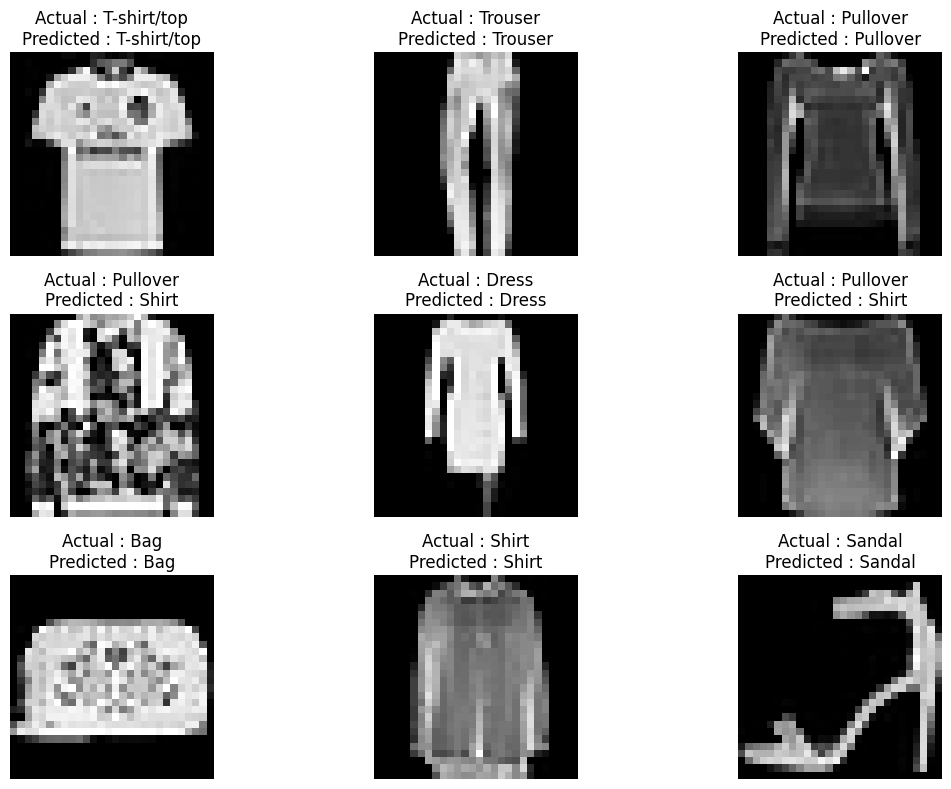

In [31]:
# Display Sample Predictions

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(

        "Actual : " + class_names[y_test[i]] +

        "\nPredicted : " + class_names[y_pred[i]]

    )

    plt.axis('off')

plt.tight_layout()

plt.show()

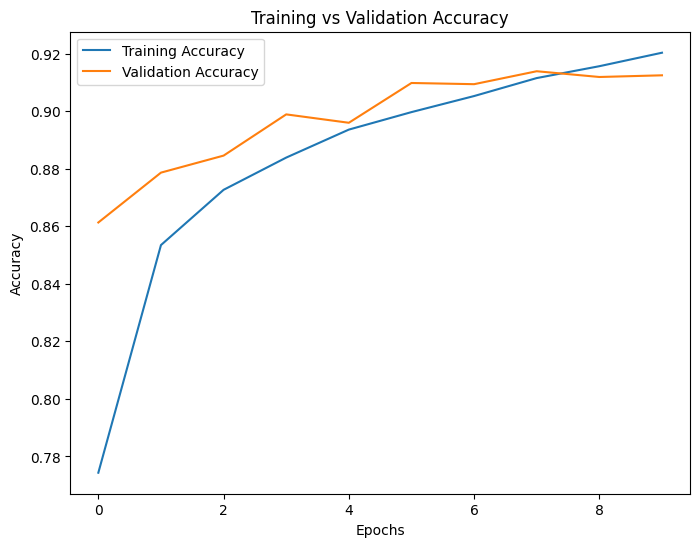

In [32]:
# Accuracy Graph

plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

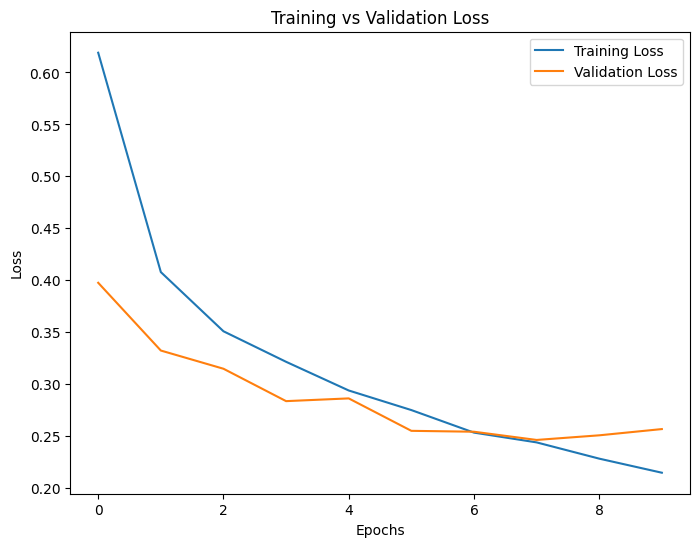

In [33]:
# Loss Graph

plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()